# Dataset

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
data = pd.read_csv(r"C:\Users\moham\OneDrive\Desktop\DEPI project\calorix_raw_dataset.csv")

In [85]:
data.head()

,recipe_id,name,name_ar,category,cuisine,difficulty,dietary_goal,meal_occasion,prep_time_min,cook_time_min,...,allergens,health_score,protein_density,glycemic_index_level,calorie_category,macro_balance_label,bmi_suitability,budget_level,avg_rating,review_count
0,100000,Grilled Chicken Breast,صدر دجاج مشوي,Main Course,Mediterranean,Easy,High Protein / Weight Loss,Dinner,8.0,19.0,...,NaN,46.8,10.65,Low,Low,High Protein,Overweight,Low,5.00,NaN
1,100001,Egg White Omelette,عجة بياض البيض,Breakfast,International,Very Easy,High Protein / Low Cal,Breakfast,6.0,6.0,...,Eggs,53.1,12.65,Low,Very Low,High Protein,Normal,Low,4.33,3.0
2,100002,Tuna Salad Bowl,بول سلطة التونة,Salad,Mediterranean,Very Easy,Weight Loss,Lunch,11.0,0.0,...,Seafood,57.0,16.14,Low,Very Low,High Protein,Overweight,Low,3.00,2.0
3,100003,Protein Pancakes,بانكيك البروتين,Breakfast,American,Very Easy,Muscle Gain,Breakfast,5.0,11.0,...,Dairy|Eggs|Gluten,51.2,8.48,Medium,Low,High Protein,Underweight,Low,5.00,2.0
4,100004,Greek Yogurt Parfait,بارفيه الزبادي اليوناني,Snack,International,Very Easy,Healthy Snack,Snack,4.0,0.0,...,Dairy,50.3,6.64,High,Low,Mixed,Normal,Low,3.43,7.0


# Data Preprocessing

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recipe_id             2062 non-null   int64  
 1   name                  2062 non-null   object 
 2   name_ar               2062 non-null   object 
 3   category              2062 non-null   object 
 4   cuisine               2062 non-null   object 
 5   difficulty            2062 non-null   object 
 6   dietary_goal          2062 non-null   object 
 7   meal_occasion         2062 non-null   object 
 8   prep_time_min         1990 non-null   float64
 9   cook_time_min         1975 non-null   float64
 10  minutes               2062 non-null   int64  
 11  n_steps               2062 non-null   int64  
 12  n_ingredients         2062 non-null   int64  
 13  servings              2062 non-null   int64  
 14  calories              2062 non-null   int64  
 15  protein_g            

In [87]:
data.shape

(2062, 38)

In [88]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2057    False
2058    False
2059    False
2060    False
2061    False
Length: 2062, dtype: bool

In [89]:
data = data.drop_duplicates()

In [90]:
data.describe()

,recipe_id,prep_time_min,cook_time_min,minutes,n_steps,n_ingredients,servings,calories,protein_g,carbohydrates_g,...,cholesterol_mg,vitamin_c_mg,calcium_mg,iron_mg,is_vegan,is_vegetarian,health_score,protein_density,avg_rating,review_count
count,2062.000000,1990.000000,1975.000000,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000,...,1881.000000,1798.000000,1841.000000,1860.000000,2062.000000,2062.000000,2062.000000,1943.000000,1801.000000,1846.000000
mean,101040.054316,9.804020,12.345316,33.314743,6.351600,8.571775,2.764791,323.890883,20.744617,32.029195,...,60.671451,22.923359,95.552960,2.583871,0.228904,0.674103,52.299661,6.232476,4.067729,5.017335
std,597.116435,5.508874,13.261085,111.377243,3.105308,6.646070,1.641132,215.885263,18.713561,17.355642,...,93.533715,23.372858,71.383521,1.440014,0.420229,0.468823,5.983566,3.294059,0.778290,5.396448
min,100000.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,-5.000000,2.000000,...,0.000000,0.500000,5.000000,0.300000,0.000000,0.000000,34.500000,0.440000,-1.000000,1.000000
25%,100524.250000,5.000000,0.000000,9.000000,4.000000,7.000000,2.000000,222.000000,9.700000,17.600000,...,0.000000,8.800000,50.000000,1.700000,0.000000,0.000000,48.300000,3.560000,3.800000,3.000000
50%,101041.500000,10.000000,10.000000,19.000000,6.000000,8.000000,2.000000,306.000000,17.100000,29.750000,...,13.000000,15.800000,70.000000,2.400000,0.000000,1.000000,52.300000,5.440000,4.200000,4.000000
75%,101558.750000,13.000000,21.000000,34.000000,9.000000,9.000000,4.000000,393.750000,30.200000,44.900000,...,85.000000,28.000000,120.000000,3.300000,0.000000,1.000000,56.700000,8.715000,4.500000,6.000000
max,102062.000000,30.000000,240.000000,1440.000000,14.000000,100.000000,12.000000,2500.000000,220.000000,78.000000,...,426.000000,142.000000,380.000000,8.000000,1.000000,1.000000,67.700000,18.350000,7.000000,59.000000


In [91]:
data.describe(include='object')

,name,name_ar,category,cuisine,difficulty,dietary_goal,meal_occasion,allergens,glycemic_index_level,calorie_category,macro_balance_label,bmi_suitability,budget_level
count,2062,2062,2062,2062,2062,2062,2062,1592,2062,2062,2062,2062,2062
unique,98,107,9,11,8,37,6,18,3,4,5,3,2
top,Stuffed Bell Peppers,دجاج مقلي بالخضار,Main Course,International,Easy,Balanced,Dinner,Dairy,Medium,Low,High Carb,Normal,Low
freq,42,42,802,905,963,293,744,255,867,1214,828,1686,1055


# Clean using fillna

encode using  LabelEncode

scale using standardScaler

for all_columns and please write notes why use each technique and explain results

In [ ]:
data.isnull().sum()

In [ ]:
(data.isnull().sum() / len(data)) * 100

In [ ]:
# data['review_count']=data['review_count'].fillna(data['review_count'].mode()[0])
# data['allergens']=data['allergens'].fillna(data['allergens'].mode()[0])
# data['prep_time_min']=data['prep_time_min'].fillna(data['prep_time_min'].mode()[0])
# data['cook_time_min']=data['cook_time_min'].fillna(data['cook_time_min'].mode()[0])
# data['saturated_fat_g']=data['saturated_fat_g'].fillna(data['saturated_fat_g'].mode()[0])
# data['fiber_g']=data['fiber_g'].fillna(data['fiber_g'].mode()[0])
# data['sodium_mg']=data['sodium_mg'].fillna(data['sodium_mg'].mode()[0])
# data['cholesterol_mg']=data['cholesterol_mg'].fillna(data['cholesterol_mg'].mode()[0])
# data['vitamin_c_mg']=data['vitamin_c_mg'].fillna(data['vitamin_c_mg'].mode()[0])
# data['calcium_mg']=data['calcium_mg'].fillna(data['calcium_mg'].mode()[0])
# data['avg_rating']=data['avg_rating'].fillna(data['avg_rating'].mode()[0])

In [ ]:
data.isnull().sum()

# EDA

Visualize patterns using seaborn, matplotlib and please explain each graph

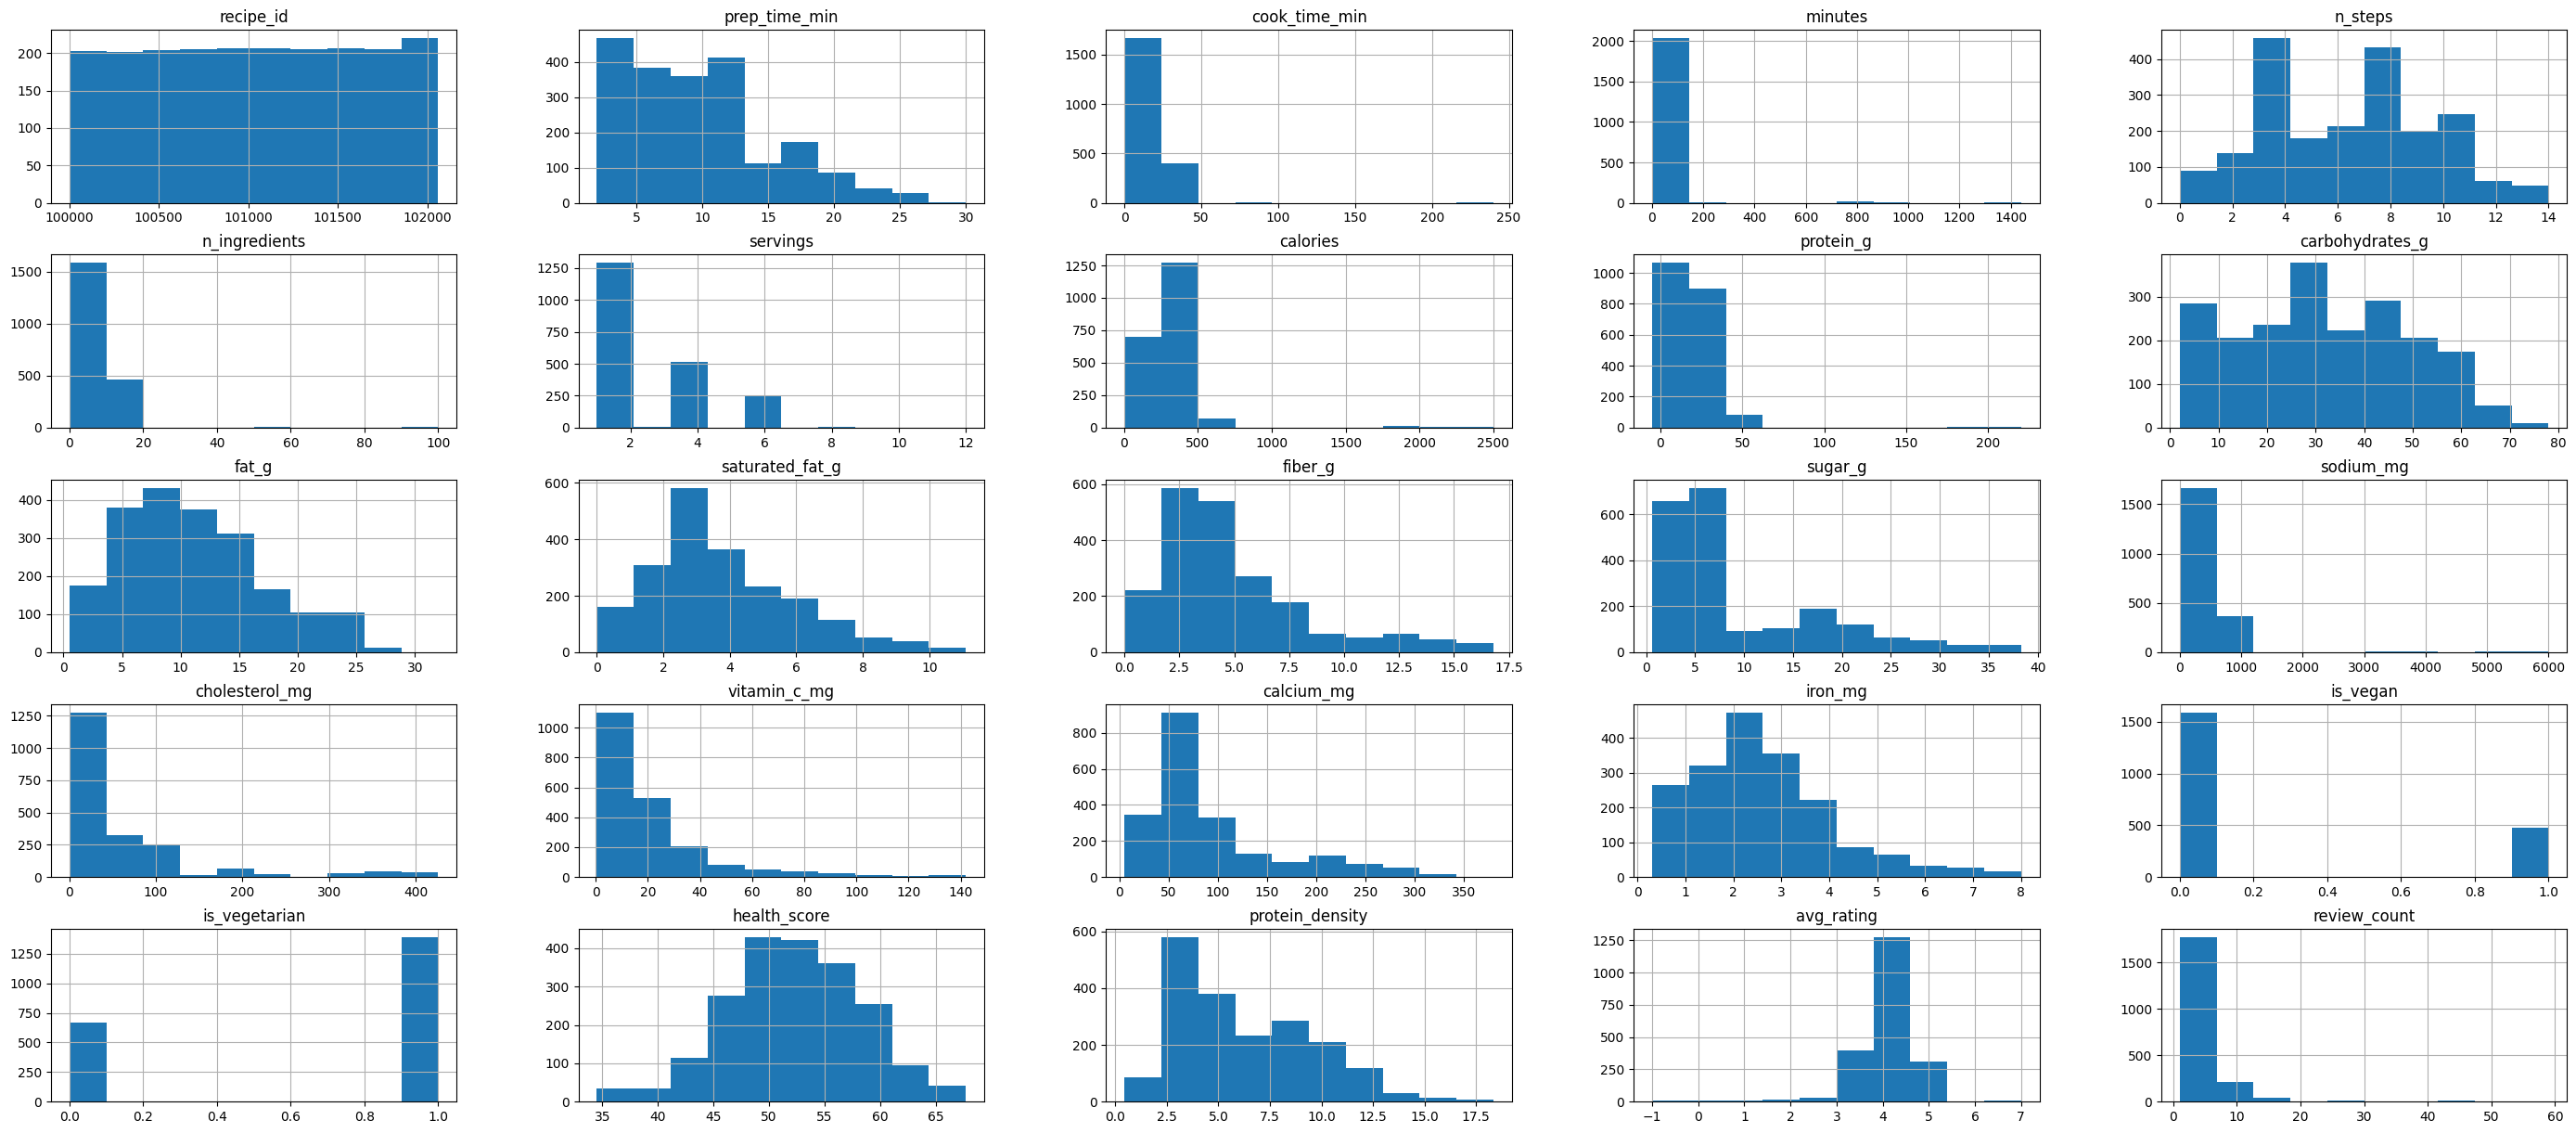

In [97]:
data.hist(figsize=(35,15))
plt.show()

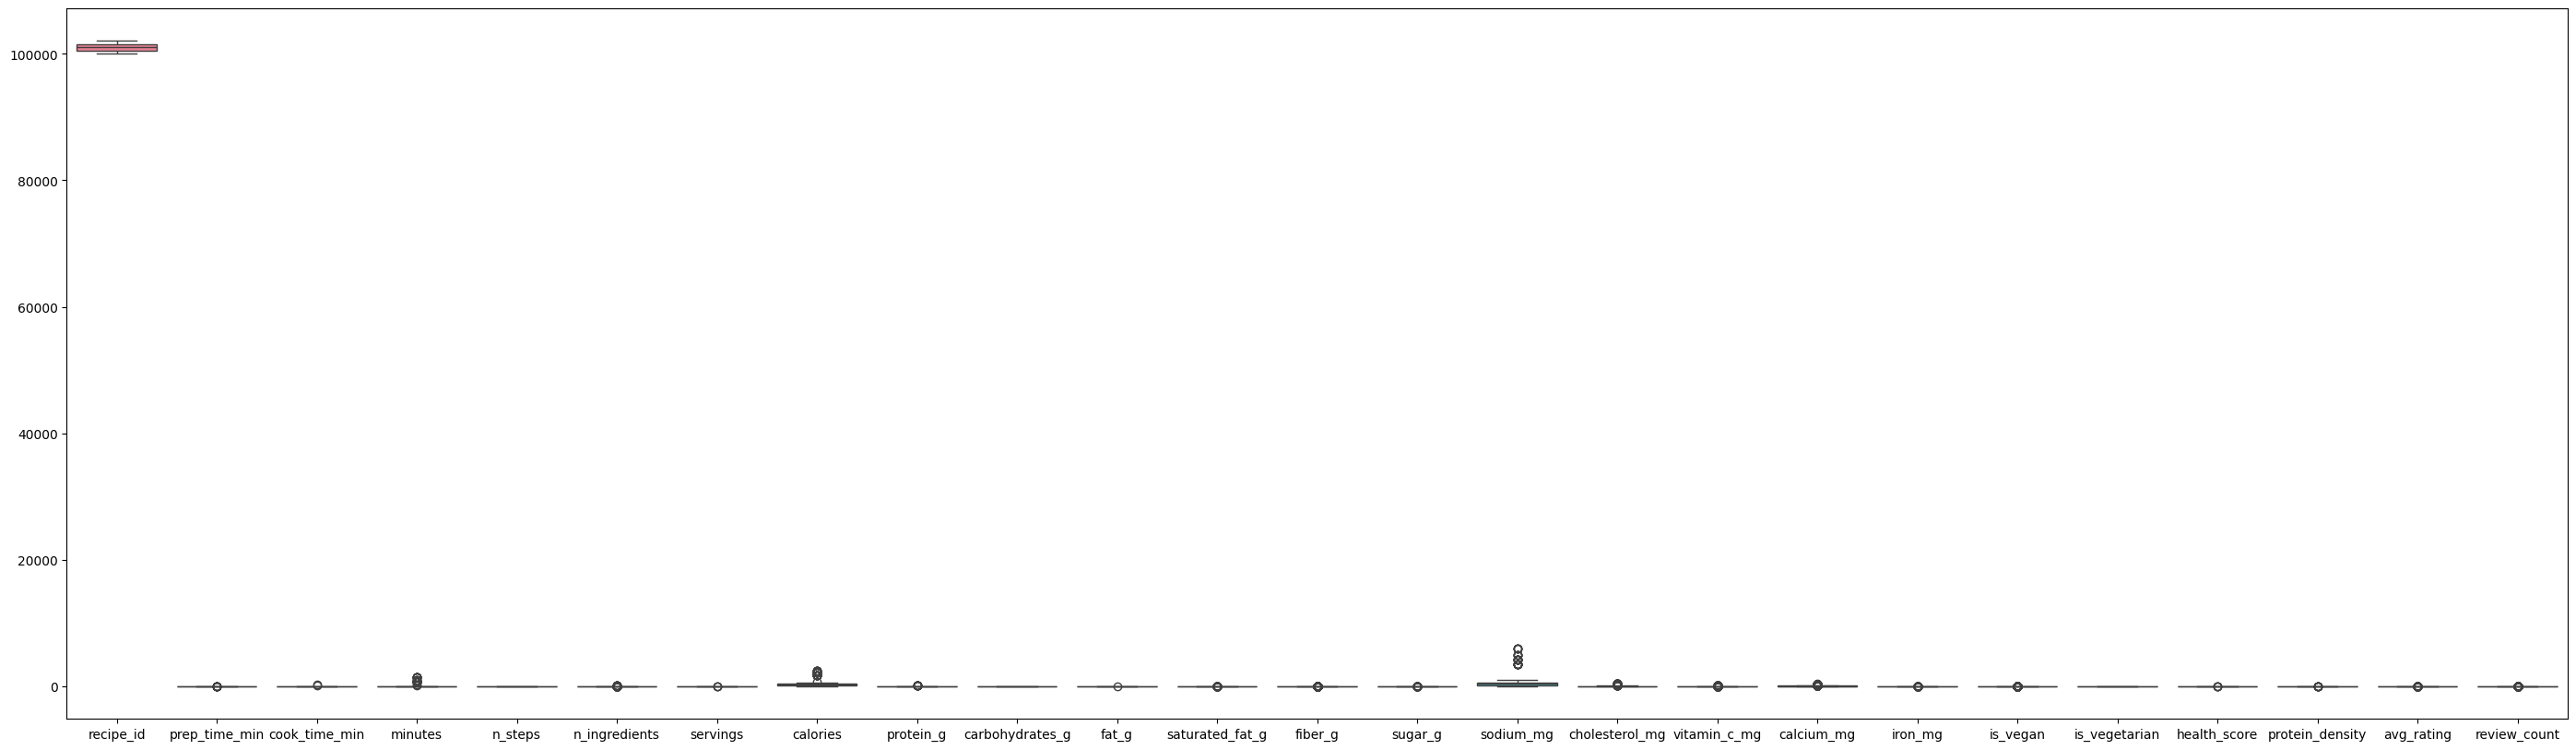

In [98]:
plt.figure(figsize=(35,10))
sns.boxplot(data=data)
plt.show()

In [99]:
for col in data.select_dtypes(include='object').columns:
    print(data[col].value_counts())
    print("-"*30)

name
Stuffed Bell Peppers      42
Minestrone Soup           42
Greek Yogurt Parfait      42
Chicken Shawarma Bowl     42
Chicken Vegetable Soup    42
                          ..
Spinach Smoothie           1
Chicken Tacos              1
Guacamole                  1
Burrito Bowl               1
Baked Sea Bass             1
Name: count, Length: 98, dtype: int64
------------------------------
name_ar
دجاج مقلي بالخضار     42
دجاج تيكا ماسالا      42
صدر دجاج مشوي         41
كرات الطاقة           41
بول أرز باللحمة       41
                      ..
طبقات زبادي يوناني     1
أرز قرنبيط مقلي        1
سموذي السبانخ          1
تاكو دجاج              1
باس البحر المشوي       1
Name: count, Length: 107, dtype: int64
------------------------------
category
Main Course      802
Breakfast        332
Snack            254
Beverage         209
Soup             170
Salad            130
Dessert           83
Light Meal        42
Dessert/Snack     40
Name: count, dtype: int64
------------------------------

# Handling Outliers

using boxplot to detect outliers and handle it using IQR

# ML_Model_1

Classify Dietary Goal

Match recipes to the right health goal automatically

Predict which goal fits the recipe (Keto / Vegan / Weight Loss…)


Algorithms: Random Forest vs KNN

X = all nutrition columns, y = dietary_goal_group

please add notes and compare results and which model is better and why and graph barchart compare results of accuracy of two models



# ML_Model_2

Predict Health Score
Score any new recipe without manually calculating it

Predict the exact health score (0–100)

Algorithms: Random Forest Regressor vs Linear Regression

X = all nutrition columns except health_score, y = health_score

please add notes and compare results and which model is better and why and graph barchart compare results of accuracy of two models


# ML_Model_3

Classify Healthy or Not
Give users a quick yes/no before choosing a recipe

Predict if recipe is healthy (1) or not (0)

Algorithms: Logistic Regression vs Decision Tree

X = all columns except is_healthy_recipe, y = is_healthy_recipe

please add notes and compare results and which model is better and why and graph barchart compare results of accuracy of two models
